In [1]:
from retirement_model import RetirementModel
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Simulation: 65.1926%
Exact value: 65.1926%


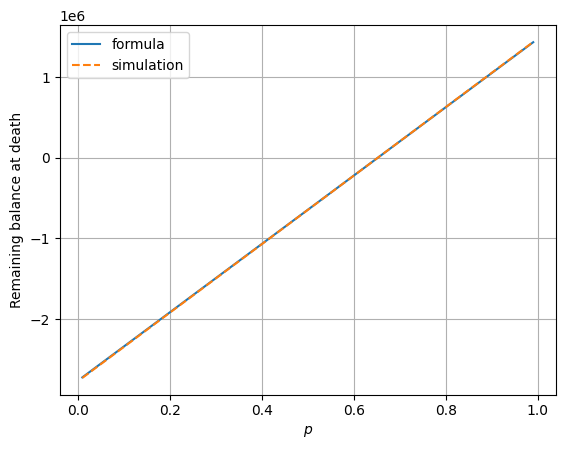

In [2]:
WORK_START = 25

BASE_PARAMS = {
        'inflation': 0.02,
        'bond_return': 0.03,
        'salary_growth': 0.05,
        't0': WORK_START,
        'T': WORK_START + 40,
        'td': WORK_START + 60
    }

model = RetirementModel(**BASE_PARAMS)

optimal_p = model.find_optimal_p()
print(f"Simulation: {optimal_p * 100:.4f}%")

p_exact = model.calculate_exact_p()
print(f"Exact value: {p_exact * 100:.4f}%")

p_list = np.linspace(0.01, 0.99)
rem_balance_formula = (
    model.calculate_total_acc_wealth(
        p=p_list) - model.calculate_retirement_pv()
) * (1 + model.monthly_bond_return) ** model.months_retired
rem_balance_sim = [model.simulate_finances(p=p) for p in p_list]
plt.plot(p_list, rem_balance_formula, label='formula')
plt.plot(p_list, rem_balance_sim, label='simulation', linestyle='--')
plt.xlabel(r'$p$')
plt.ylabel('Remaining balance at death')
plt.legend()
plt.grid()
plt.show()

In [3]:
def _calculate_savings_trajectory(base_params, target_param, param_range):
    """Loops through a specified range for a single parameter and returns the exact p values."""
    p_values = []
    params = base_params.copy()
    
    for val in param_range:
        params[target_param] = val
        model = RetirementModel(**params)
        p_values.append(model.calculate_exact_p())
        
    return np.array(p_values) * 100


def _plot_individual_sensitivity(param_range, p_values, cfg):
    """Generates an independent individual figure for a 1D sensitivity parameter."""
    plt.figure(figsize=(7, 4.5))
    
    # Scale X coordinates to percentage if configured
    x_plot = param_range * 100 if cfg.get("scale_x_pct") else param_range
    
    plt.plot(x_plot, p_values, color=cfg["color"], lw=2)
    plt.title(cfg["title"], fontsize=12, fontweight='bold')
    plt.xlabel(cfg["x_label"])
    plt.ylabel(r"Required Savings Rate $p$ (%)")
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()


def run_sensitivity_analysis(base_params):
    rates_range = np.linspace(0.0, 0.10, 100)
    
    scenarios = [
        {
            "target_param": "salary_growth", "range": rates_range, "scale_x_pct": True,
            "color": "crimson", "title": r"Impact of Salary Growth ($I$)", "x_label": "Annual Salary Growth (%)"
        },
        {
            "target_param": "bond_return", "range": rates_range, "scale_x_pct": True,
            "color": "forestgreen", "title": r"Impact of Bond Return ($c$)", "x_label": "Annual Bond Return (%)"
        },
        {
            "target_param": "inflation", "range": rates_range, "scale_x_pct": True,
            "color": "darkorange", "title": r"Impact of Inflation ($\Pi$)", "x_label": "Annual Inflation (%)"
        },
        {
            "target_param": "T", "range": np.arange(50, 75).astype(int), "scale_x_pct": False,
            "color": "royalblue", "title": r"Impact of Retirement Age ($T$)", "x_label": r"Retirement Age ($T$)"
        },
        {
            "target_param": "t0", "range": np.arange(20, 35).astype(int), "scale_x_pct": False,
            "color": "purple", "title": r"Impact of Starting Age ($t_0$)", "x_label": r"Starting Age ($t_0$)"
        },
        {
            "target_param": "td", "range": np.arange(70, 100).astype(int), "scale_x_pct": False,
            "color": "black", "title": r"Impact of Age of Death ($t_d$)", "x_label": r"Age of Death ($t_d$)"
        }
    ]

    for cfg in scenarios:
        p_trajectory = _calculate_savings_trajectory(
            base_params=base_params, 
            target_param=cfg["target_param"], 
            param_range=cfg["range"]
        )
        
        _plot_individual_sensitivity(
            param_range=cfg["range"], 
            p_values=p_trajectory, 
            cfg=cfg
        )

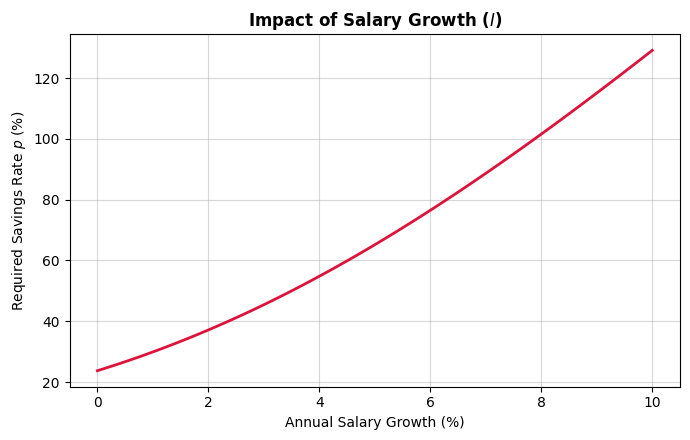

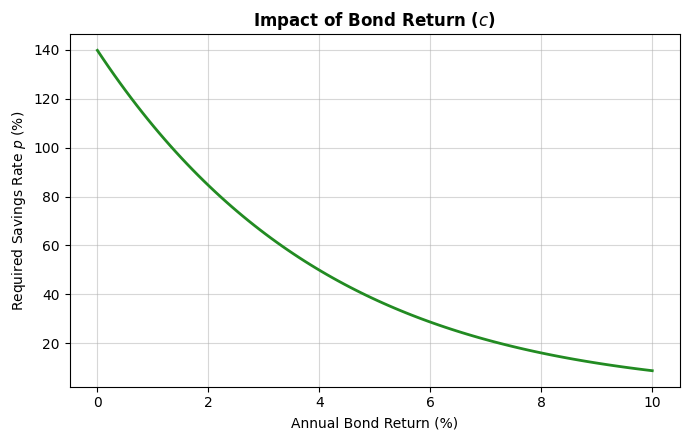

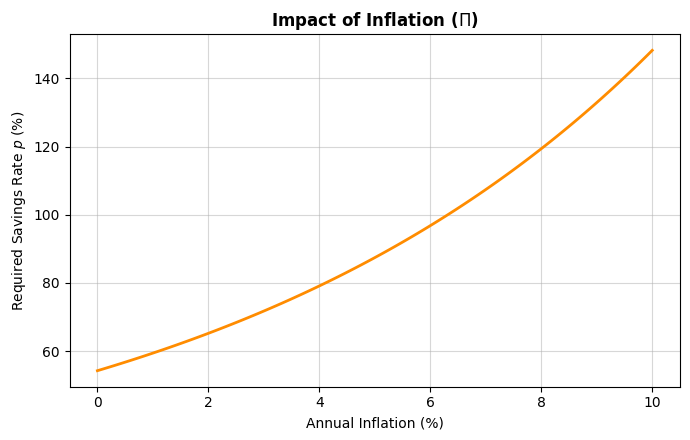

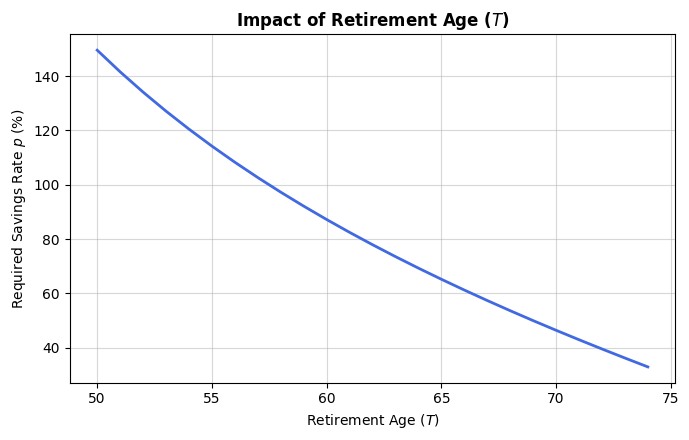

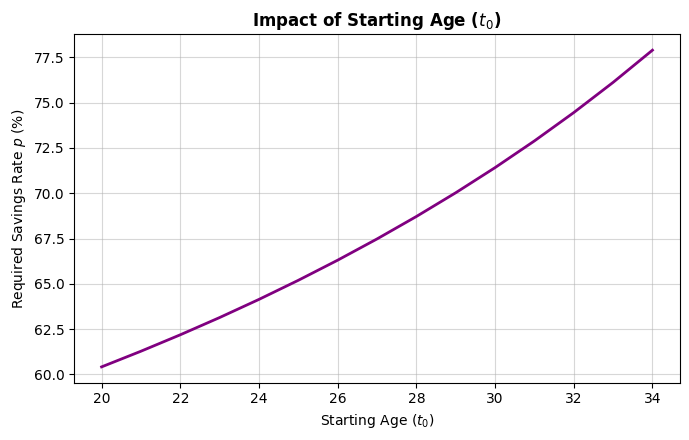

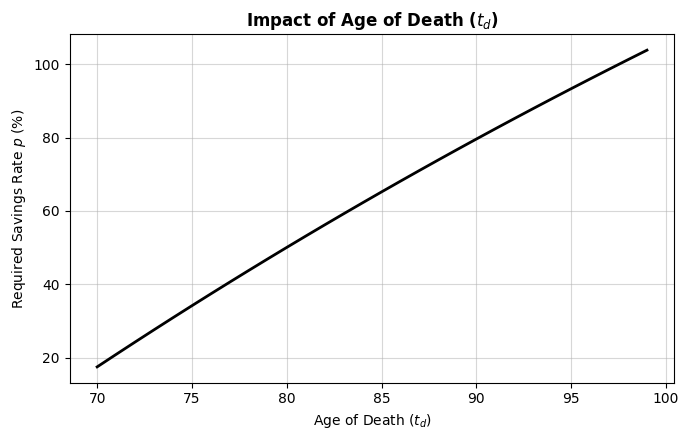

In [4]:
run_sensitivity_analysis(BASE_PARAMS)

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def _run_interaction_grid(base_params, p1_name, p1_vals, p2_name, p2_vals):
    """Generates the meshgrid and computes the clipped savings rate matrix."""
    P1_grid, P2_grid = np.meshgrid(p1_vals, p2_vals)
    results = np.zeros(P1_grid.shape)
    
    params = base_params.copy()
    
    for i in range(P1_grid.shape[0]):
        for j in range(P1_grid.shape[1]):
            params[p1_name] = P1_grid[i, j]
            params[p2_name] = P2_grid[i, j]
            
            model = RetirementModel(**params)

            raw_p = model.calculate_exact_p()
            results[i, j] = np.clip(raw_p, 0, 1) * 100
            
    return P1_grid, P2_grid, results


def _plot_contour_interaction(x_grid, y_grid, z_grid, cfg):
    """Plots an isolated contour chart for a specific parameter pair interaction."""
    plt.figure(figsize=(8, 6.5))
    
    x_plot = x_grid * 100 if cfg.get("scale_x_pct") else x_grid
    y_plot = y_grid * 100 if cfg.get("scale_y_pct") else y_grid
    
    contour = plt.contourf(x_plot, y_plot, z_grid, levels=20, cmap='viridis_r')
    plt.colorbar(contour, label=r"Required $p$ (%)")
    
    lines = plt.contour(x_plot, y_plot, z_grid, levels=cfg["levels"], colors='white', linewidths=0.5)
    plt.clabel(lines, inline=True, fmt='%1.0f%%', fontsize=9, colors='white')
    
    plt.plot(cfg["base_pt"][0], cfg["base_pt"][1], 'ro', markersize=8, label=cfg["base_label"])
    
    plt.title(cfg["title"], fontsize=12, fontweight='bold')
    plt.xlabel(cfg["x_label"])
    plt.ylabel(cfg["y_label"])
    plt.legend(loc=cfg["legend_loc"])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_extended_interactions(base_params):
    interaction_configs = [
        {
            "p1_name": "bond_return", "p1_vals": np.linspace(0.01, 0.08, 50),
            "p2_name": "inflation", "p2_vals": np.linspace(0.00, 0.06, 50),
            "scale_x_pct": True, "scale_y_pct": True,
            "levels": [10, 25, 40, 55, 70, 85],
            "title": r"Interaction: Bond Yield ($c$) vs Inflation ($\Pi$)",
            "x_label": r"Annual Bond Return $c$ (%)", "y_label": r"Annual Inflation $\Pi$ (%)",
            "base_pt": (3, 2), "base_label": r'Base Case (c=3%, $\Pi$=2%)', "legend_loc": "upper right"
        },
        {
            "p1_name": "T", "p1_vals": np.linspace(50, 70, 50),
            "p2_name": "t0", "p2_vals": np.linspace(20, 35, 50),
            "scale_x_pct": False, "scale_y_pct": False,
            "levels": [20, 40, 60, 80],
            "title": r"Interaction: Retirement ($T$) vs Starting Age ($t_0$)",
            "x_label": r"Retirement Age $T$ (years)", "y_label": r"Career Starting Age $t_0$ (years)",
            "base_pt": (65, 25), "base_label": r'Base Case ($T$=65, $t_0$=25)', "legend_loc": "lower left"
        },
        {
            "p1_name": "td", "p1_vals": np.linspace(70, 100, 50),
            "p2_name": "T", "p2_vals": np.linspace(50, 70, 50),
            "scale_x_pct": False, "scale_y_pct": False,
            "levels": [20, 40, 60, 80],
            "title": r"Interaction: Lifespan ($t_d$) vs Retirement ($T$)",
            "x_label": r"Age of Death $t_d$ (years)", "y_label": r"Retirement Age $T$ (years)",
            "base_pt": (85, 65), "base_label": r'Base Case (td=85, T=65)', "legend_loc": "lower right"
        }
    ]

    # Process and build each isolated interaction chart sequentially
    for cfg in interaction_configs:
        x_grid, y_grid, z_grid = _run_interaction_grid(
            base_params, 
            p1_name=cfg["p1_name"], p1_vals=cfg["p1_vals"],
            p2_name=cfg["p2_name"], p2_vals=cfg["p2_vals"]
        )
        
        _plot_contour_interaction(x_grid, y_grid, z_grid, cfg)



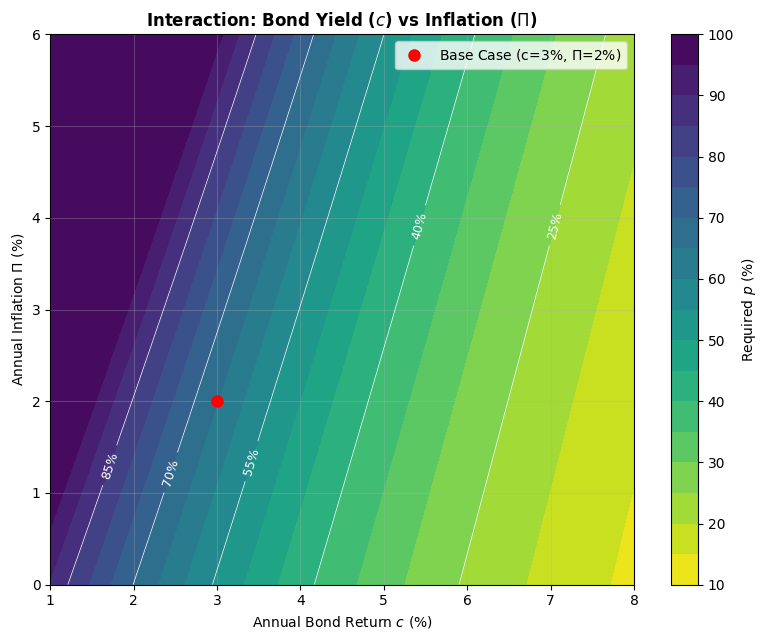

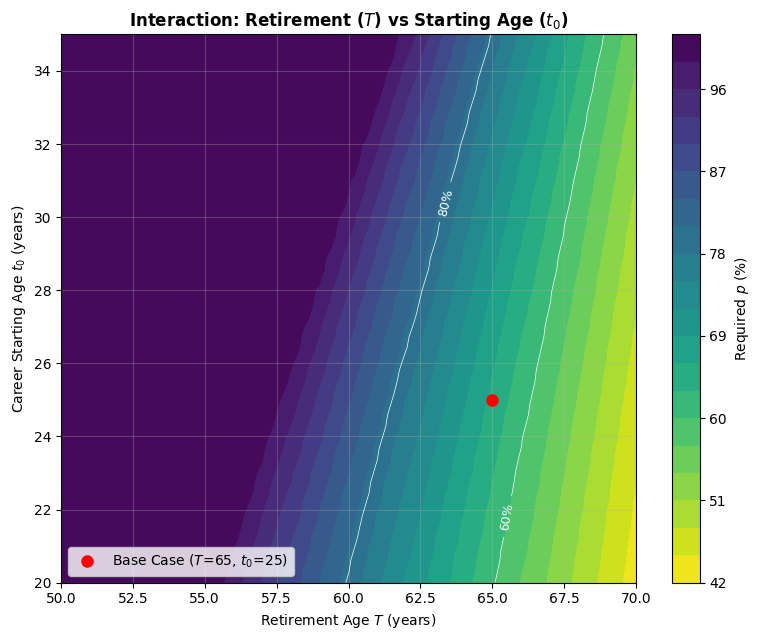

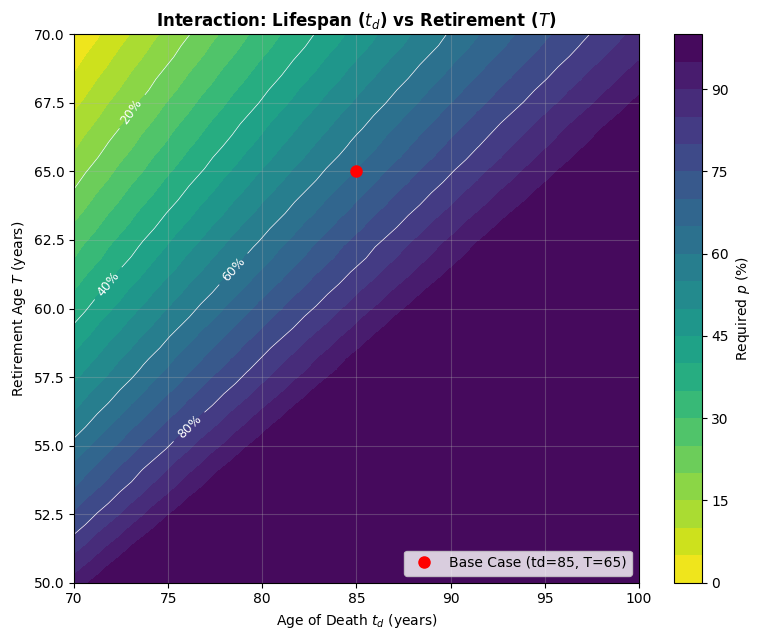

In [6]:
plot_extended_interactions(BASE_PARAMS)

Your observation about the bond having no assumed maturity is excellent and hits on one of the most unrealistic aspects of basic financial modeling.

Here is how this assumption works mathematically, why it is structurally flawed in reality, and how we can use this exact insight to draft a comprehensive answer for **Part 3** of your project.

---

### How the "No Maturity" Bond Works in the Model

In the real world, individual bonds have a fixed maturity date (e.g., 5, 10, or 30 years) at which point the issuer returns your principal, and the bond ceases to exist.

Because your model spans **60 years** ($t_0=0$ to $t_d=60$), treating the bond return $c$ as a flat, uninterrupted constant means the model is making one of two implicit assumptions:

1. **The Reinvestment Assumption (Rolling Portfolio):** It assumes that every time a bond matures, you immediately take 100% of the principal and cash payouts and buy a brand-new bond. Crucially, it assumes that the new bond will yield the *exact same* 3% annual return.
2. **The Bond Fund / Bond Ladder Analogy:** It mimics a rolling "bond ladder" or a constant-maturity bond ETF. In a bond ladder, you buy bonds with staggered maturities (e.g., some maturing in 1 year, some in 2, some in 3). As the shortest one matures, you reinvest it at the long end of the ladder. This creates a perpetual stream of interest that smoothens out over time, approximating a continuous asset.

#### The Hidden Flaw: Reinvestment Risk

By ignoring maturity, the model completely eliminates **reinvestment risk** and **interest rate risk**. In the real world, interest rates fluctuate wildly. If you buy a 10-year bond at 3%, but interest rates crash to 1% by year 10, when your bond matures you cannot reinvest it at 3% anymore. Your retirement path would be derailed.

---

### Part 3: Model Assumptions, Critical Flaws, and Mitigations

To earn the full 2 points for this section, you need to systematically list the core assumptions, pinpoint the most dangerous ones, and suggest real-world adjustments to make the model realistic.

#### 1. Core Assumptions of the Baseline Model

* **Constant Economic Rates:** Inflation ($\Pi=2\%$), investment returns ($c=3\%$), and salary growth ($I=5\%$) remain perfectly unchanged for 720 consecutive months (60 years).
* **Perpetual Investment Liquidity & Constant Yield:** As discussed, bonds have no maturity, no default risk, and face no reinvestment risk.
* **Deterministic Lifespan:** The exact date of death ($t_d=60$) is known with 100% certainty at age 0. There is no longevity risk.
* **Frictionless Economy:** There are no transaction fees, asset management fees, capital gains taxes, or income taxes.
* **Perfect Pension Target:** The model assumes your retirement expenses must *exactly* equal your highest final career salary, requiring a 100% replacement rate.
* **Continuous Employment:** There are no career gaps, periods of unemployment, or early partial retirements.

#### 2. Which Assumptions are the Most Critical?

* **The Constant Spread Risk ($c < I$ and $c > \Pi$):** The assumption that bond yields remain static over 60 years is highly dangerous. Historically, macroeconomic regimes change. If inflation spikes (like a period of hyperinflation), a fixed 3% bond yield means your real purchasing power vanishes. Furthermore, expecting bonds ($3\%$) to consistently underperform salary growth ($5\%$) for 40 years straight forces an incredibly high savings rate ($p \approx 65\%$), which is practically impossible for a consumer.
* **The Certainty of Death ($t_d$):** In reality, you cannot plan your wealth to hit exactly 0 at a pre-set age. If you optimize your savings to run out at age 60, but you accidentally live to age 65, you face 5 years of complete financial ruin. This is known as **Longevity Risk**.

#### 3. How to Mitigate and Balance the Model for Reality

To make this model close to what financial planners actually use in the industry, you should propose the following mitigations in your report:

* **Introduce Stochastic Volatility (Part 4 Preview):** Instead of constant rates, model returns as random variables. For instance, bond returns can be modeled using a random walk or a mean-reverting interest rate model (like the Cox-Ingersoll-Ross model) to simulate fluctuating yields and maturity reinvestment cycles.
* **Incorporate Lifespan Probability (Actuarial Tables):** Instead of a fixed $t_d$, integrate conditional survival probabilities from national actuarial life tables. The model should optimize $p$ so that the probability of running out of money before death is below a safe threshold (e.g., a 95% success rate).
* **Introduce Multi-Asset Dynamic Allocation (Lifecycle/Target-Date Funds):** Relying 100% on bonds during the working phase is inefficient. Real-world modeling utilizes a mix of stocks (high growth, high risk) and bonds (low growth, low risk). A young worker starts with 90% stocks to beat salary growth, and gradually shifts toward bonds as retirement ($T$) approaches to lock in capital.
* **Account for Taxes and Fees:** Introduce a flat capital gains tax (e.g., *Podatek Belki* in Poland) and realistic fund management fees (0.5%–1% annually), which drastically reduce the compound interest denominator.

---

This bridges the gap perfectly. Your critique of the bond maturity is exactly the kind of independent, critical financial thinking professors look for in Part 3.

Are you ready to move on to **Part 4**, where we actually implement a dynamic stock market index with up and down probabilities to solve these exact efficiency problems?

In [7]:
import pandas as pd

# df_sp500 = pd.read_csv('sp500.csv')
# df_sp500['Nominal_Return'] = pd.to_numeric(df_sp500['Value']) / 100
# df_sp500['Year'] = pd.to_datetime(df_sp500['Date']).dt.year

df_sp500 = pd.read_csv('sp500-stern.csv')

df_sp500['Nominal_Return'] = (
    df_sp500['S&P 500 (includes dividends)']
    .str.rstrip('%')
    .astype(float)
    / 100
)

df_sp500['Year'] = pd.to_numeric(df_sp500['Year'])

df_inf_raw = pd.read_csv('inflation.csv')
df_us_raw = df_inf_raw[df_inf_raw['Country Code'] == 'USA']

year_cols = [col for col in df_us_raw.columns if col.isdigit()]

df_us_long = pd.melt(
    df_us_raw,
    id_vars=['Country Name', 'Country Code'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Inflation_Rate'
)

df_us_long['Year'] = df_us_long['Year'].astype(int)
df_us_long['Inflation_Rate'] = pd.to_numeric(df_us_long['Inflation_Rate']) / 100

df_merged = pd.merge(df_sp500, df_us_long, on='Year', how='inner')
df_merged['Real_Return'] = ((1 + df_merged['Nominal_Return']) / (1 + df_merged['Inflation_Rate'])) - 1

START_YEAR = 1980
df = df_merged.loc[df_merged['Year'] >= START_YEAR].copy()

print(df['Nominal_Return'].mean())
df.head()

0.13403695652173914


,Year,S&P 500 (includes dividends),Nominal_Return,Country Name,Country Code,Inflation_Rate,Real_Return
20,1980,31.74%,0.3174,United States,USA,0.135492,0.160202
21,1981,-4.70%,-0.0470,United States,USA,0.103347,-0.136265
22,1982,20.42%,0.2042,United States,USA,0.061314,0.134631
23,1983,22.34%,0.2234,United States,USA,0.032124,0.185322
24,1984,6.15%,0.0615,United States,USA,0.043005,0.017732


In [8]:
up_years = df[df['Real_Return'] >= 0]
down_years = df[df['Real_Return'] < 0]

qu_real = up_years['Real_Return'].mean()
qd_real = down_years['Real_Return'].mean()
pu_real = len(up_years) / len(df)
pd_real = len(down_years) / len(df)

print(f"Parameters calculated from {START_YEAR} onwards (adjusted for inflation):")
print(f"qu = {qu_real:.4f} | qd = {qd_real:.4f} | pu = {pu_real:.4f} | pd = {pd_real:.4f}")

up_years = df[df['Nominal_Return'] >= 0]
down_years = df[df['Nominal_Return'] < 0]
qu_nominal = up_years['Nominal_Return'].mean()
qd_nominal = down_years['Nominal_Return'].mean()
pu_nominal = len(up_years) / len(df)
pd_nominal = len(down_years) / len(df)

print(f"Parameters calculated from {START_YEAR} onwards (nominal):")
print(f"qu = {qu_nominal:.4f} | qd = {qd_nominal:.4f} | pu = {pu_nominal:.4f} | pd = {pd_nominal:.4f}")


Parameters calculated from 1980 onwards (adjusted for inflation):
qu = 0.1660 | qd = -0.1429 | pu = 0.7609 | pd = 0.2174
Parameters calculated from 1980 onwards (nominal):
qu = 0.1911 | qd = -0.1368 | pu = 0.8261 | pd = 0.1739


Check if this roughly makes sense.
[Some website](https://www.fidelity.com/learning-center/trading-investing/sp-500-average-return) says the average (nominal) was 10%.

In [9]:
def average_return(qu, qd, pu):
    avg_return = qu * pu + qd * (1 - pu)
    return avg_return

In [10]:
average_nominal = average_return(qu_nominal, qd_nominal, pu_nominal)
print(average_nominal)

0.13403695652173914


[This source](https://curvo.eu/backtest/en/market-index/sp-500?currency=usd) confirms it:
* annual growth rate: 10.85%
* standard deviation: 14.68%

In [11]:
def std_dev_return(qu, qd, pu):
    variance = (qu**2 * pu + qd**2 * (1 - pu)) \
            - (qu * pu + qd * (1 - pu))**2
    
    return np.sqrt(variance)

In [12]:
std_dev_nominal = std_dev_return(qu_nominal, qd_nominal, pu_nominal)
print(std_dev_nominal)

0.12426278288606168


Average real return and standard devation

In [13]:
average_real = average_return(qu_real, qd_real, pu_real)
std_dev_real = std_dev_return(qu_real, qd_real, pu_real)

print(average_real)
print(std_dev_real)

0.09216555800444823
0.13178378739479782


In [14]:
qu, qd, pu = qu_real, qd_real, pu_real

In [15]:
start_weights = [0.0, 0.7, 0.8, 0.9, 1.0]
end_weights = [0.0, 0.2, 0.3, 0.4, 0.5]
best_p, best_strategy = model.optimize_portfolio(qu, qd, pu, start_weights, end_weights, verbose=True)

Starting portfolio optimization...
Strategy [0% -> 0%]: Necessary p = 65.3%
Strategy [70% -> 0%]: Necessary p = 60.7%
Strategy [70% -> 20%]: Necessary p = 52.7%
Strategy [70% -> 30%]: Necessary p = 50.4%
Strategy [70% -> 40%]: Necessary p = 48.1%
Strategy [70% -> 50%]: Necessary p = 46.6%
Strategy [80% -> 0%]: Necessary p = 60.0%
Strategy [80% -> 20%]: Necessary p = 51.9%
Strategy [80% -> 30%]: Necessary p = 49.6%
Strategy [80% -> 40%]: Necessary p = 47.7%
Strategy [80% -> 50%]: Necessary p = 45.8%
Strategy [90% -> 0%]: Necessary p = 59.6%
Strategy [90% -> 20%]: Necessary p = 51.5%
Strategy [90% -> 30%]: Necessary p = 48.9%
Strategy [90% -> 40%]: Necessary p = 46.9%
Strategy [90% -> 50%]: Necessary p = 45.4%
Strategy [100% -> 0%]: Necessary p = 58.8%
Strategy [100% -> 20%]: Necessary p = 50.8%
Strategy [100% -> 30%]: Necessary p = 48.1%
Strategy [100% -> 40%]: Necessary p = 46.2%
Strategy [100% -> 50%]: Necessary p = 44.6%
----------------------------------------
Optimal portfolio foun

In [16]:
def report_final_balance_dist(balances, success_rate):
    print(f"Probability of not running out of money before death: {success_rate:.2f}%")
    print(f"Median Remaining Wealth at Death: ${np.median(balances):,.2f}")

    plt.figure(figsize=(10, 6))
    plt.hist(balances / 1e6, bins=100, color='teal', edgecolor='black', alpha=0.7)
    plt.axvline(0, color='red', linestyle='--', lw=2, label='Bankruptcy Line')
    plt.title(f"Distribution of Final Wealth at Death (Savings Rate $p$ = {best_p*100:.2f}%)", fontsize=14, fontweight='bold')
    plt.xlabel("Remaining Capital at Death (Millions USD)")
    plt.ylabel("Number of Simulated Lifetimes")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Probability of not running out of money before death: 95.13%
Median Remaining Wealth at Death: $3,233,926.51


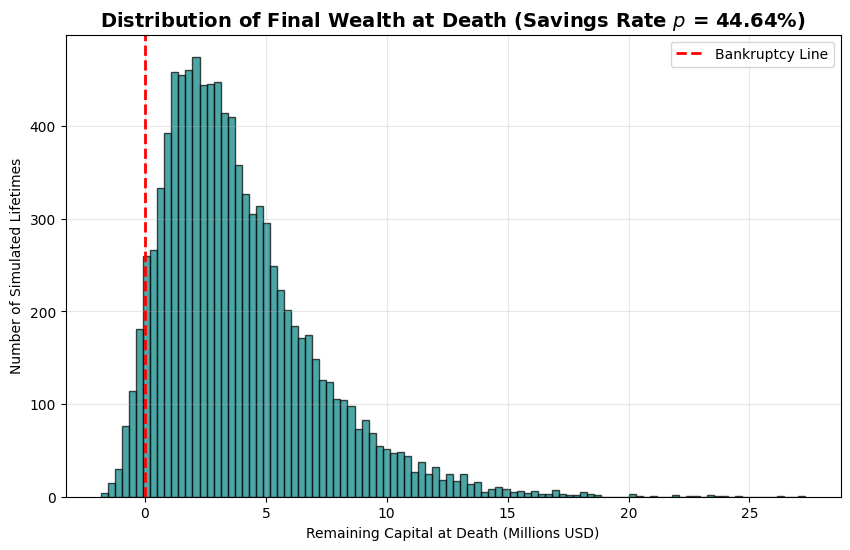

In [17]:
sw_start, sw_end = best_strategy
balances, success_rate = model.run_vectorized_mc(best_p, sw_start, sw_end, qu, qd, pu)

report_final_balance_dist(balances, success_rate)

In [18]:
def compare_strategies(sw_start, sw_end, qu, qd, pu):
    savings_rates = np.linspace(0.2, 0.7)
    results_bonds = []
    results_optimal = []

    for p in savings_rates:
        # Bonds only
        #_, sr1 = model.run_vectorized_mc(p, 0, 0, qu_real, qd_real, pu_real) 
        sr1 = 100 if model.simulate_finances(p) > 0 else 0
        _, sr2 = model.run_vectorized_mc(p, sw_start, sw_end, qu, qd, pu)
        results_bonds.append(sr1)
        results_optimal.append(sr2)

    plt.plot(savings_rates, results_bonds, label='Bonds Only')
    plt.plot(savings_rates, results_optimal, label='Optimal Glide Path')
    plt.axhline(y=95, linestyle='--', color='gray', label=r'95% threshold')
    plt.xlabel('Savings Rate (p)')
    plt.ylabel('Success Rate (%)')
    plt.legend()
    plt.show()

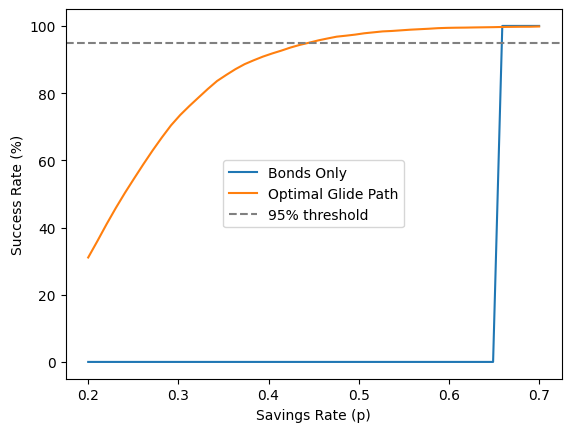

In [19]:
compare_strategies(sw_start, sw_end, qu, qd, pu)

In [20]:
def run_sensitivity_analysis(qu, qd, pu, base_params, param1_name, param1_vals, param2_name, param2_vals):
    """
    Loops through a 2D grid, returning two DataFrames:
    1. Numerical savings rates (p) for heatmap coloring.
    2. Formatted string labels containing both (p) and the optimal portfolio glidepath.
    """
    grid_shape = (len(param2_vals), len(param1_vals))
    results_p = np.zeros(grid_shape)
    
    annot_labels = np.empty(grid_shape, dtype=object)

    params = base_params.copy()
    
    for i, val2 in enumerate(param2_vals):
        for j, val1 in enumerate(param1_vals):
            params[param1_name] = val1
            params[param2_name] = val2
            
            model = RetirementModel(**params)
            best_p, best_strategy = model.optimize_portfolio(
                qu=qu, qd=qd, pu=pu,
                start_weights=[0.7, 0.8, 0.9, 1.0],
                end_weights=[0.2, 0.3, 0.4, 0.5]
            )
            
            p_pct = np.clip(best_p, 0, 1) * 100
            results_p[i, j] = p_pct
            
            if best_strategy is not None:
                start_w, end_w = best_strategy
            
                annot_labels[i, j] = f"{p_pct:.1f}%\n[{start_w:.1f}→{end_w:.1f}]"
            else:
                annot_labels[i, j] = f"{p_pct:.1f}%\n[N/A]"
            
    df_p = pd.DataFrame(results_p, index=param2_vals, columns=param1_vals)
    df_annot = pd.DataFrame(annot_labels, index=param2_vals, columns=param1_vals)
            
    return df_p, df_annot


def plot_sensitivity_heatmap(df_p, df_annot, title, x_label, y_label, is_pct_axis=False):
    """Plots the heatmap using df_p for colors and df_annot for custom cell text."""
    plt.figure(figsize=(9, 7)) 

    df_p_flipped = df_p.iloc[::-1]
    df_annot_flipped = df_annot.iloc[::-1]
    
    x_tick_labels = [f"{x*100:.1f}%" if is_pct_axis else f"{x:.0f}" for x in df_p_flipped.columns]
    y_tick_labels = [f"{y*100:.1f}%" if is_pct_axis else f"{y:.0f}" for y in df_p_flipped.index]
    
    sns.heatmap(
        df_p_flipped,
        annot=df_annot_flipped,
        fmt="",
        cmap="YlGnBu",
        xticklabels=x_tick_labels,
        yticklabels=y_tick_labels,
        annot_kws={"size": 9}
    )
    
    plt.title(title, fontsize=12, fontweight='bold', pad=15)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.tight_layout()
    plt.show()


def generate_sensitivity_heatmaps(qu, qd, pu, base_params):
    NUM_POINTS_RATES = 3
    NUM_POINTS_AGES = 3 

    heatmap_configs = [
        {
            "p1_name": "bond_return", 
            "p1_vals": np.linspace(0.01, 0.05, NUM_POINTS_RATES),
            "p2_name": "inflation", 
            "p2_vals": np.linspace(0.01, 0.04, NUM_POINTS_RATES),
            "title": "Sensitivity of Optimal Savings Rate (p) and Glidepath [Start→End]",
            "x_label": "Bond Real Return (c)", 
            "y_label": "Inflation Rate (Π)",
            "is_pct": True
        },
        {
            "p2_name": "t0", 
            "p2_vals": np.linspace(20, 35, NUM_POINTS_AGES).astype(int),
            "p1_name": "T", 
            "p1_vals": np.linspace(50, 70, NUM_POINTS_AGES).astype(int),
            "title": "Sensitivity of Optimal Savings Rate (p) and Glidepath [Start→End]",
            "y_label": r"Career Starting Age $t_0$ (years)", 
            "x_label": r"Retirement Age $T$ (years)",
            "is_pct": False
        },
        {
            "p2_name": "T", 
            "p2_vals": np.linspace(50, 70, NUM_POINTS_AGES).astype(int),
            "p1_name": "td", 
            "p1_vals": np.linspace(70, 100, NUM_POINTS_AGES).astype(int),
            "title": "Sensitivity of Optimal Savings Rate (p) and Glidepath [Start→End]",
            "y_label": r"Retirement Age $T$ (years)", 
            "x_label": r"Age of Death $t_d$ (years)",
            "is_pct": False
        }
    ]

    for config in heatmap_configs:
        print(f"Generating sensitivity matrix for {config['x_label']} vs {config['y_label']}...")
        
        df_grid, df_labels = run_sensitivity_analysis(
            qu=qu, qd=qd, pu=pu, 
            base_params=base_params,
            param1_name=config["p1_name"], 
            param1_vals=config["p1_vals"],
            param2_name=config["p2_name"], 
            param2_vals=config["p2_vals"]
        )
        
        plot_sensitivity_heatmap(
            df_p=df_grid, 
            df_annot=df_labels,
            title=config["title"], 
            x_label=config["x_label"], 
            y_label=config["y_label"],
            is_pct_axis=config["is_pct"]
        )

Generating sensitivity matrix for Bond Real Return (c) vs Inflation Rate (Π)...


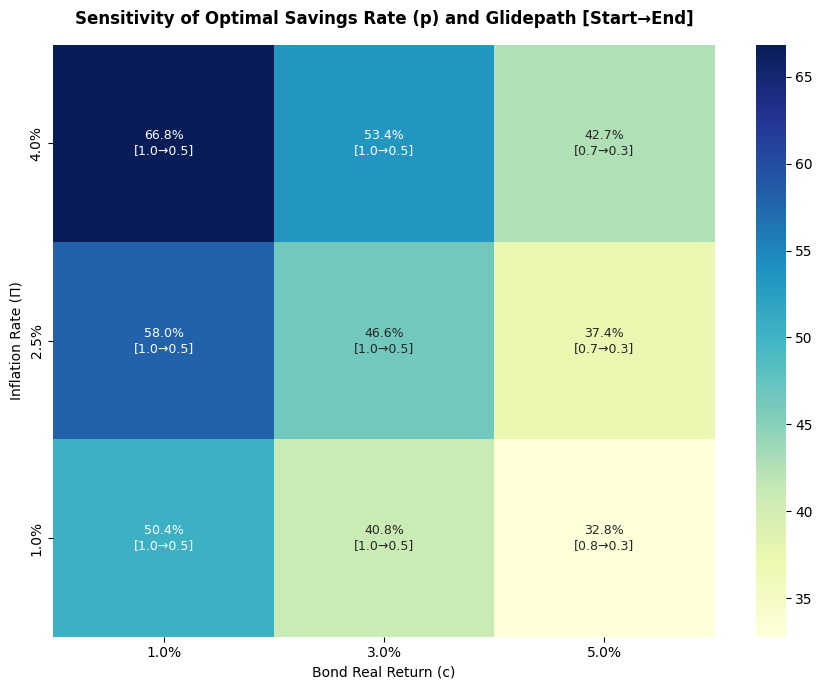

Generating sensitivity matrix for Retirement Age $T$ (years) vs Career Starting Age $t_0$ (years)...


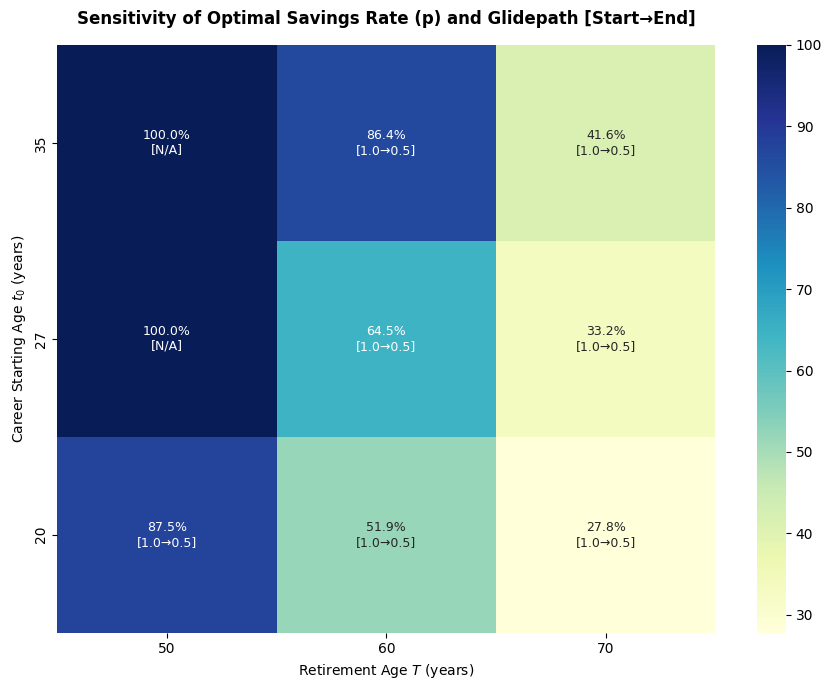

Generating sensitivity matrix for Age of Death $t_d$ (years) vs Retirement Age $T$ (years)...


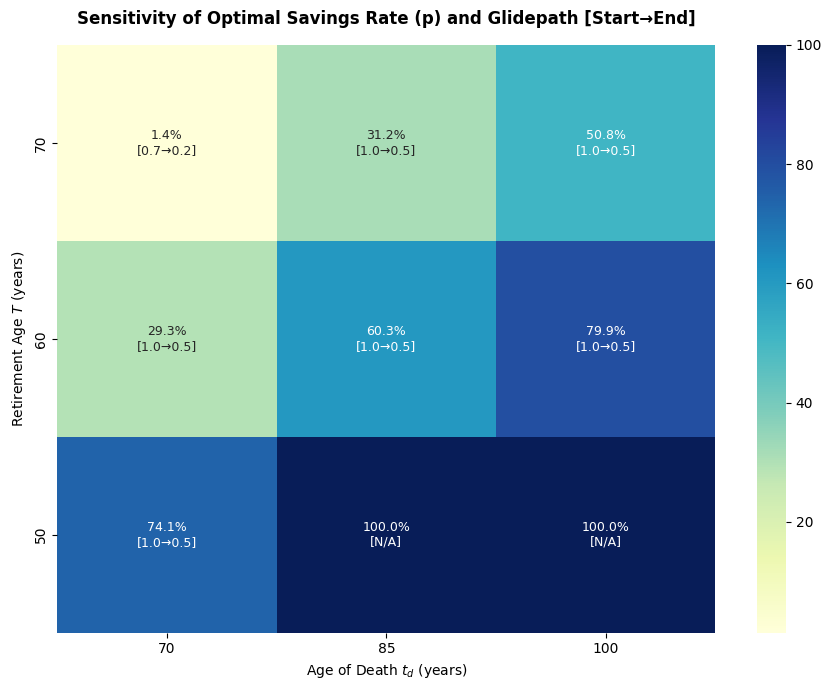

In [21]:
generate_sensitivity_heatmaps(qu, qd, pu, BASE_PARAMS)

In [22]:
def _calculate_optimized_trajectory(qu, qd, pu, base_params, target_param, param_range):
    """Loops through a range for a single parameter and runs optimize_portfolio, returning data and labels."""
    p_values = []
    strategy_labels = []
    params = base_params.copy()
    
    for val in param_range:
        params[target_param] = val
        model = RetirementModel(**params)

        best_p, best_strategy = model.optimize_portfolio(
            qu=qu, qd=qd, pu=pu,
            start_weights=[0.7, 0.8, 0.9, 1.0],
            end_weights=[0.2, 0.3, 0.4, 0.5]
        )
        
        p_val = best_p if best_p is not None else 0.0
        p_values.append(np.clip(p_val, 0, 1))
        
        if best_strategy is not None:
            start_w, end_w = best_strategy
            strategy_labels.append(f"[{start_w:.1f}→{end_w:.1f}]")
        else:
            strategy_labels.append("[N/A]")
        
    return np.array(p_values) * 100, strategy_labels


def _plot_individual_optimized_sensitivity(param_range, p_values, strategy_labels, cfg):
    """Generates an individual figure for optimized sensitivity with text label overlays."""
    plt.figure(figsize=(8, 5))
    
    x_plot = param_range * 100 if cfg.get("scale_x_pct") else param_range
    
    plt.plot(x_plot, p_values, color=cfg["color"], marker='o', lw=2, markersize=6)
    
    for x, y, label in zip(x_plot, p_values, strategy_labels):
        plt.annotate(
            label,
            xy=(x, y),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            fontweight="bold",
            color="#333333",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.7, lw=0.5)
        )
    
    y_min, y_max = np.min(p_values), np.max(p_values)
    if y_max > y_min:
        plt.ylim(y_min - (y_max - y_min)*0.1, y_max + (y_max - y_min)*0.15)
    else:
        plt.ylim(y_min - 5, y_max + 5)

    plt.title(cfg["title"], fontsize=12, fontweight='bold', pad=15)
    plt.xlabel(cfg["x_label"])
    plt.ylabel(r"Optimal Savings Rate $p$ (%)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def run_optimized_sensitivity_analysis(qu, qd, pu, base_params):
    NUM_POINTS_RATES = 5
    NUM_POINTS_AGES = 5

    rates_range = np.linspace(0.01, 0.1, NUM_POINTS_RATES)
    t0_range = np.linspace(20, 35, NUM_POINTS_AGES).astype(int)
    T_range = np.linspace(50, 70, NUM_POINTS_AGES).astype(int)
    td_range = np.linspace(75, 95, NUM_POINTS_AGES).astype(int)
    
    scenarios = [
        {
            "target_param": "salary_growth", "range": rates_range, "scale_x_pct": True,
            "color": "crimson", "title": r"Impact of Salary Growth ($I$)", "x_label": "Annual Salary Growth (%)"
        },
        {
            "target_param": "bond_return", "range": rates_range, "scale_x_pct": True,
            "color": "forestgreen", "title": r"Impact of Bond Return ($c$)", "x_label": "Annual Bond Return (%)"
        },
        {
            "target_param": "inflation", "range": rates_range, "scale_x_pct": True,
            "color": "darkorange", "title": r"Impact of Inflation ($\Pi$)", "x_label": "Annual Inflation (%)"
        },
        {
            "target_param": "T", "range": T_range, "scale_x_pct": False,
            "color": "royalblue", "title": r"Impact of Retirement Age ($T$)", "x_label": r"Retirement Age ($T$)"
        },
        {
            "target_param": "t0", "range": t0_range, "scale_x_pct": False,
            "color": "purple", "title": r"Impact of Starting Age ($t_0$)", "x_label": r"Starting Age ($t_0$)"
        },
        {
            "target_param": "td", "range": td_range, "scale_x_pct": False,
            "color": "black", "title": r"Optimized Impact of Age of Death ($t_d$)", "x_label": r"Age of Death ($t_d$)"
        }
    ]

    for cfg in scenarios:
        print(f"Running optimized tracking for: {cfg['target_param']}...")
        
        p_trajectory, strategy_labels = _calculate_optimized_trajectory(
            qu=qu, qd=qd, pu=pu,
            base_params=base_params, 
            target_param=cfg["target_param"], 
            param_range=cfg["range"]
        )
        
        _plot_individual_optimized_sensitivity(
            param_range=cfg["range"], 
            p_values=p_trajectory, 
            strategy_labels=strategy_labels,
            cfg=cfg
        )

Running optimized tracking for: salary_growth...


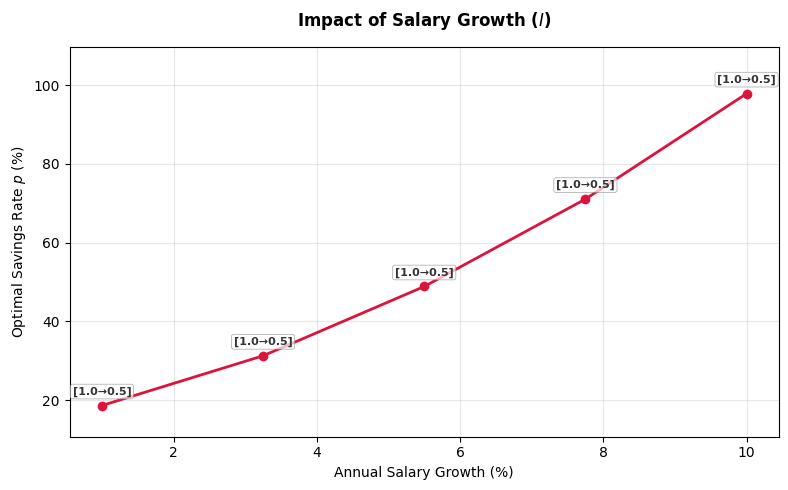

Running optimized tracking for: bond_return...


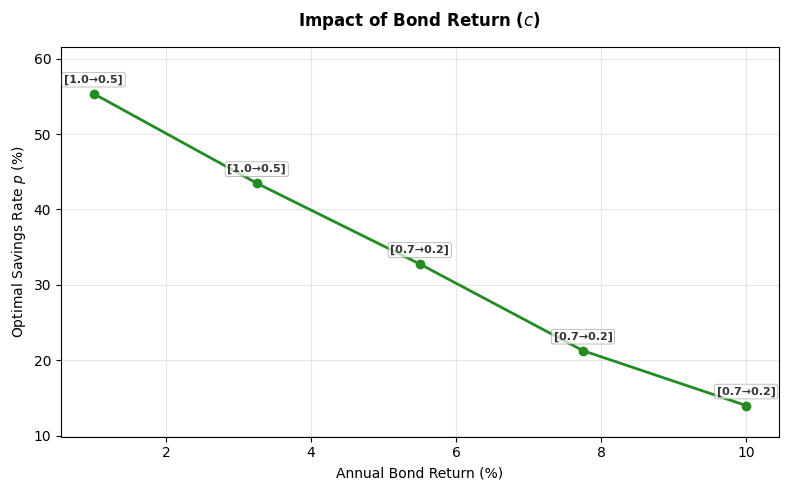

Running optimized tracking for: inflation...


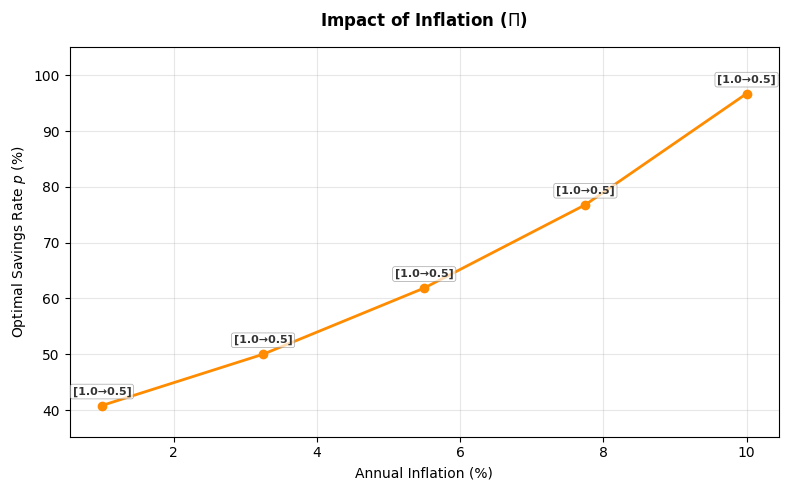

Running optimized tracking for: T...


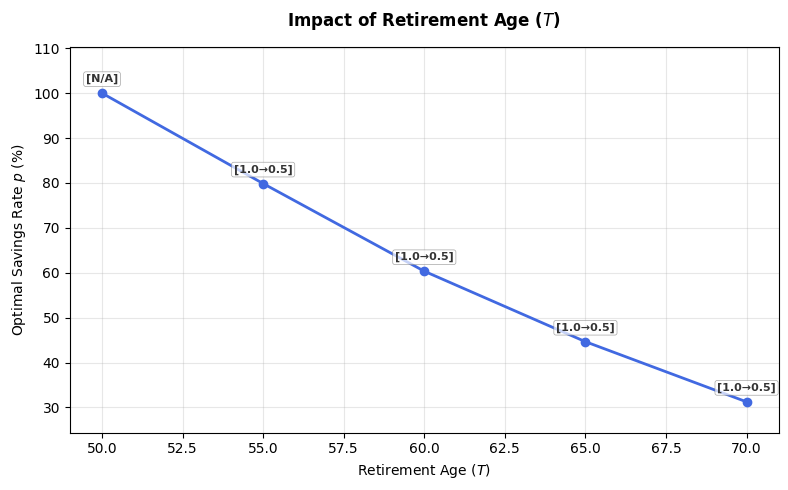

Running optimized tracking for: t0...


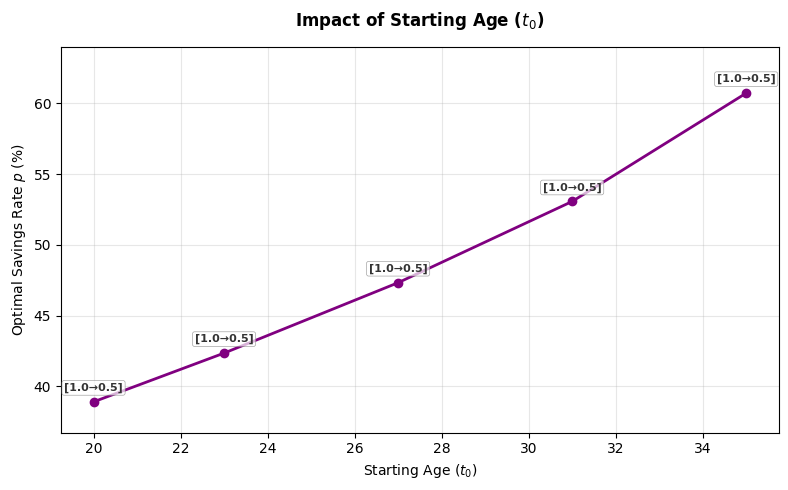

Running optimized tracking for: td...


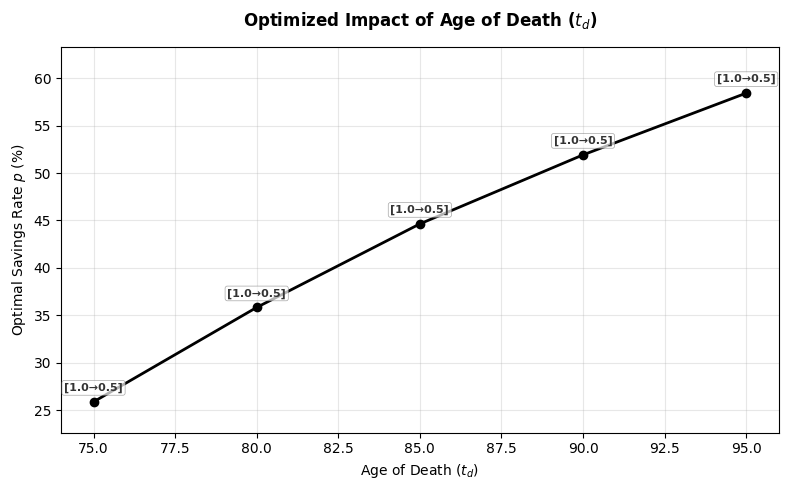

In [23]:
run_optimized_sensitivity_analysis(qu, qd, pu, BASE_PARAMS)